In [8]:
# cil imports
from cil.framework import ImageData, ImageGeometry
from cil.framework import AcquisitionGeometry, AcquisitionData

from cil.plugins.astra.operators import ProjectionOperator

from cil.utilities.display import show2D

# External imports
from phantominator import shepp_logan
import numpy as np


# Make explicit Radon transform

Input

In [9]:
# number of pixels and angles
n_pixels = 50
n_angles = 90

# other input
cmap = 'rainbow'
device = 'cpu'

Set up phantom

In [10]:

# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)


# Setup acquisition geometry
# with sufficient number of projections
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)
size_phantom = phantom.shape

c:\Users\P285563\AppData\Local\miniconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


Create implicit projection operator and sinogram

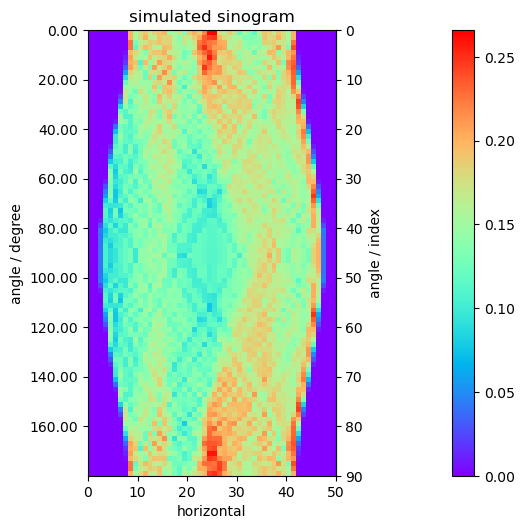

In [11]:
# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

# Visualise data
show2D(sino, 'simulated sinogram', cmap=cmap, size=(10,10), origin='upper-left')

Make explicit A_radon

In [12]:
zero_image = ig.allocate(0.0)
size_sino = sino.size
total_pixels = n_pixels ** 2

A_radon = np.zeros((size_sino, total_pixels))

pixel_index = 0
for pixel_number_y in range(n_pixels):
    for pixel_number_x in range(n_pixels):
        zero_image.as_array()[pixel_number_y, pixel_number_x] = 1.0

        sinogram_basis = A.direct(zero_image).as_array()

        A_radon[:, pixel_index] = sinogram_basis.reshape(size_sino,)

        zero_image.as_array()[pixel_number_y, pixel_number_x] = 0.0
        pixel_index = pixel_index + 1

print('The size of A_radon is', A_radon.shape)

The size of A_radon is (4500, 2500)


Check the sinogram is the same

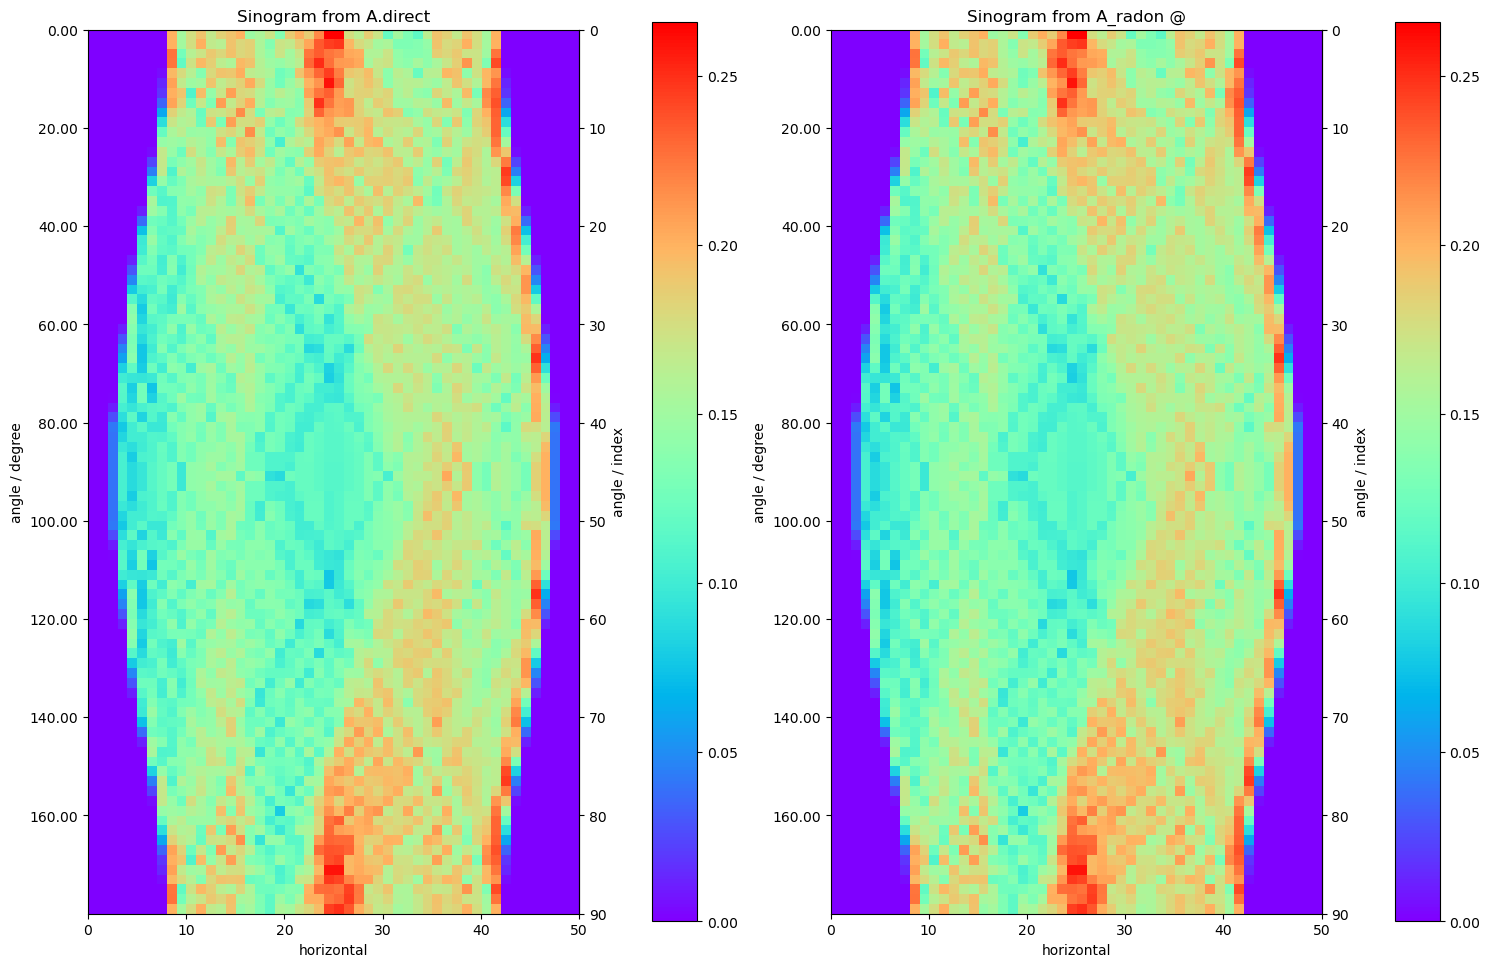

c:\Users\P285563\AppData\Local\miniconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


1.4940350436868888e-06

In [16]:
sino_new = A_radon @ phantom.as_array().reshape(total_pixels,)
sino_new = AcquisitionData(sino_new.reshape(sino.shape), geometry=ag)


# Visualise data
show2D([sino, sino_new], ['Sinogram from A.direct', 'Sinogram from A_radon @'], \
       cmap=cmap, num_cols=3, size=(15,10), origin='upper-left')

diff = sino-sino_new
diff.norm()